## Ejercicio 1

**(a)** Para analizar cómo se degrada la información de los datos a medida que se eliminan 
componentes, se aplicará PCA a cada una de las clases por separado. Para cada clase del dataset, 
reducir la dimensión de los datos a $K$ componentes principales, considerando diferentes valores 
de este parámetro:

$$K = 1, 2, 3, 4, 5, 10, 20, 50, 100, 200, 500, 784$$

Calcular en cada caso la **varianza explicada** y el **error cuadrático medio (MSE)**. Graficar 
las 4 curvas de *varianza explicada vs. K* para las clases utilizadas. Hacer lo mismo con las 
curvas de *MSE vs. K*. Analice los resultados obtenidos.

---

**(b)** Para cada clase, elegir una imagen particular y graficar:

- **(i)** Imagen original
- **(ii)** Imagen reducida y reconstruida con $K = 50$
- **(iii)** Imagen reducida y reconstruida con $K = 2$

Justifique las diferencias observadas.

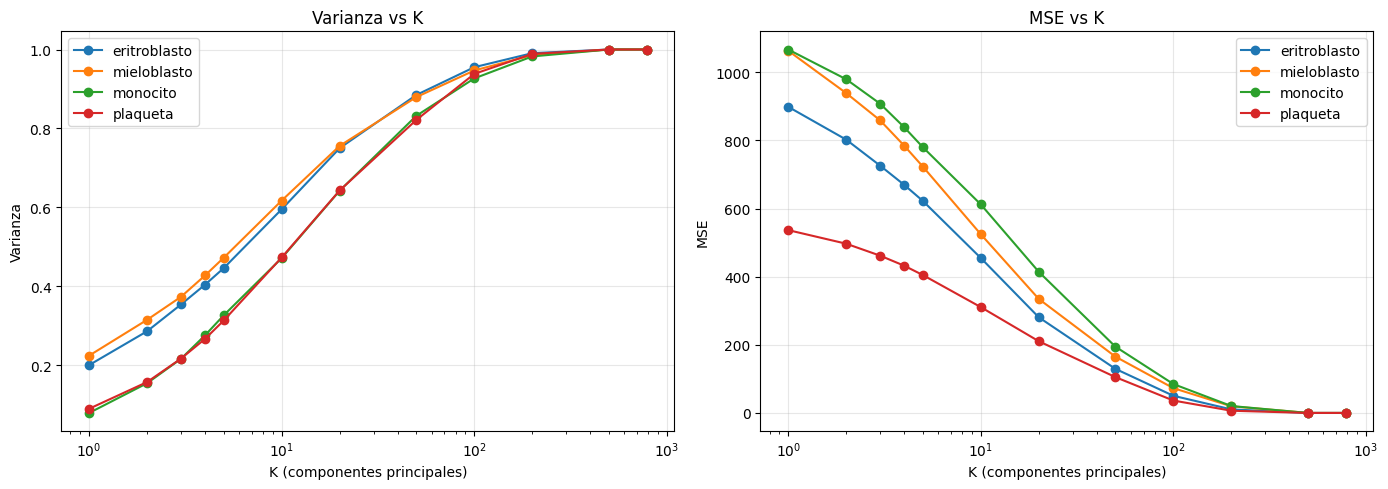

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
DATA_SET = "dataset"
CLASES = ["eritroblasto", "mieloblasto", "monocito", "plaqueta"]
N_IMG = 500
K_VALS = [1, 2, 3, 4, 5, 10, 20, 50, 100, 200, 500, 784]
SEMILLA = 42
np.random.seed(SEMILLA)

def cargar_imagenes(clase: str, n: int) -> np.ndarray:
    carpeta = os.path.join(DATA_SET, clase)
    archivos = [f for f in os.listdir(carpeta) if f.endswith(('.png', '.jpg', '.jpeg'))]
    elegidos = np.random.choice(archivos, size=n, replace=False)

    datos = []
    for archivo in elegidos:
        img = Image.open(os.path.join(carpeta, archivo)).convert("L")
        datos.append(np.array(img).flatten())
    
    return np.array(datos, dtype=float)

def hacer_pca(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    mu = X.mean(axis=0)
    X_Centrada = X - mu
    
    Covarianza = np.cov(X_Centrada, rowvar=False)
    Autovalores, Autovectores = np.linalg.eigh(Covarianza) 
    
    idx = np.argsort(Autovalores)[::-1] #mayor a menor
    Autovalores = Autovalores[idx]
    Autovectores = Autovectores[:, idx]
    return mu, Autovalores, Autovectores, X_Centrada

def reconstruir(X_Centrada: np.ndarray, Autovectores: np.ndarray, K: int) -> np.ndarray:
    P_K = Autovectores[:, :K]
    Y = X_Centrada @ P_K 
    X_recuperada = Y @ P_K.T
    return X_recuperada

resultados = {}
for clase in CLASES:
    Datos_Clase = cargar_imagenes(clase, N_IMG)
    mu, Autovalores, Autovectores, X_Centrada = hacer_pca(Datos_Clase)
    Suma_Autovalores = Autovalores.sum()
    
    Lista_Varianzas, mses = [], []
    for K in K_VALS:
        Varianza_explicada  = Autovalores[:K].sum() / Suma_Autovalores
        Lista_Varianzas.append(Varianza_explicada)

        X_recuperada = reconstruir(X_Centrada, Autovectores, K)
        mse = np.mean((X_Centrada - X_recuperada) ** 2)
        mses.append(mse)

    resultados[clase] = {"Varianzas Explicadas": Lista_Varianzas, "mse": mses,"mu": mu, "autovalores": Autovalores,
    "autovectores": Autovectores,"X_Centrada": X_Centrada, "Datos de la Clase": Datos_Clase}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, clase in enumerate(CLASES):
    axes[0].plot(K_VALS, resultados[clase]["Varianzas Explicadas"], marker='o', label=clase)
    axes[1].plot(K_VALS, resultados[clase]["mse"], marker='o', label=clase)

axes[0].set_ylabel("Varianza")
axes[0].set_title("Varianza vs K")

axes[1].set_ylabel("MSE")
axes[1].set_title("MSE vs K")

for i in range(2):
    axes[i].set_xlabel("K (componentes principales)")
    axes[i].set_xscale('log')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

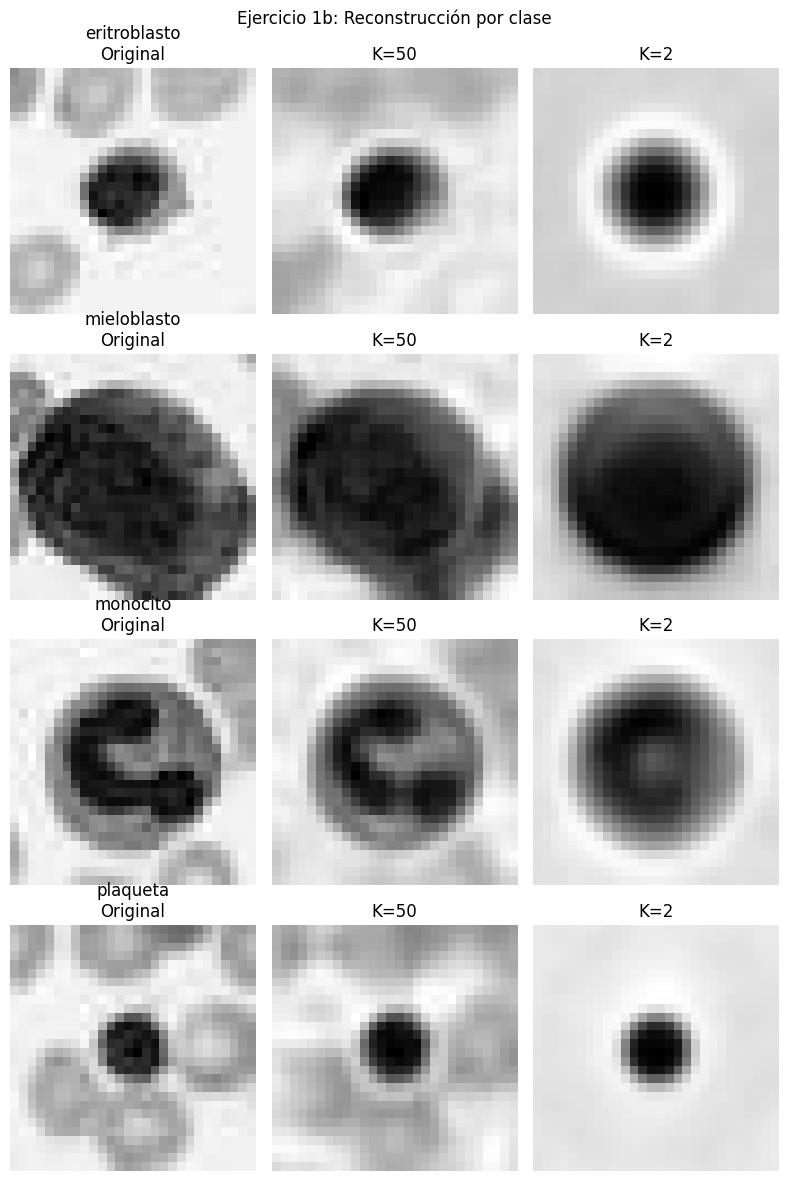

In [45]:
fig, axes = plt.subplots(4, 3, figsize=(8, 12))

for i, clase in enumerate(CLASES):
    X = resultados[clase]["Datos de la Clase"]
    X_Centrada = resultados[clase]["X_Centrada"]
    mu = resultados[clase]["mu"]
    Autovectores = resultados[clase]["autovectores"]

    img_orig = X[0].reshape(28, 28) 

    rec_50 = (reconstruir(X_Centrada, Autovectores, K=50)[0] + mu).reshape(28, 28)
    rec_2 = (reconstruir(X_Centrada, Autovectores, K=2)[0] + mu).reshape(28, 28)

    axes[i][0].imshow(img_orig, cmap='gray')
    axes[i][0].set_title(f"{clase}\nOriginal")
    axes[i][0].axis('off')

    axes[i][1].imshow(rec_50, cmap='gray')
    axes[i][1].set_title("K=50")
    axes[i][1].axis('off')

    axes[i][2].imshow(rec_2, cmap='gray')
    axes[i][2].set_title("K=2")
    axes[i][2].axis('off')

plt.suptitle("Ejercicio 1b: Reconstrucción por clase")
plt.tight_layout()
plt.show()


## Ejercicio 2

### (a) Clasificación K-NN sin reducción de dimensionalidad

Aplicar un modelo de clasificación utilizando los **vectores completos** (sin reducción de dimensionalidad) como entrada del modelo **K-NN**, y calcular el *accuracy* sobre el conjunto de prueba.

### (b) Clasificación K-NN con PCA

Aplicar nuevamente el modelo de clasificación, pero esta vez utilizando como vector de entrada los **datos reducidos mediante PCA** para distintos valores de $K$ (los mismos que en el Ejercicio 1).

- Calcular y **graficar** el *accuracy* en función de $K$
- Comparar los resultados con el *accuracy* obtenido sin aplicar PCA
- Justificar lo observado

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

X_total = np.vstack([resultados[c]["Datos de la Clase"] for c in CLASES])
y_total = np.hstack([np.full(N_IMG, i)  for i, c in enumerate(CLASES)])

X_train, X_test, y_train, y_test = train_test_split(X_total, y_total, test_size=0.3, stratify=y_total, random_state=SEMILLA)

Clasificador = KNeighborsClassifier(n_neighbors=5)
Clasificador.fit(X_train, y_train)
precision = accuracy_score(y_test, Clasificador.predict(X_test))

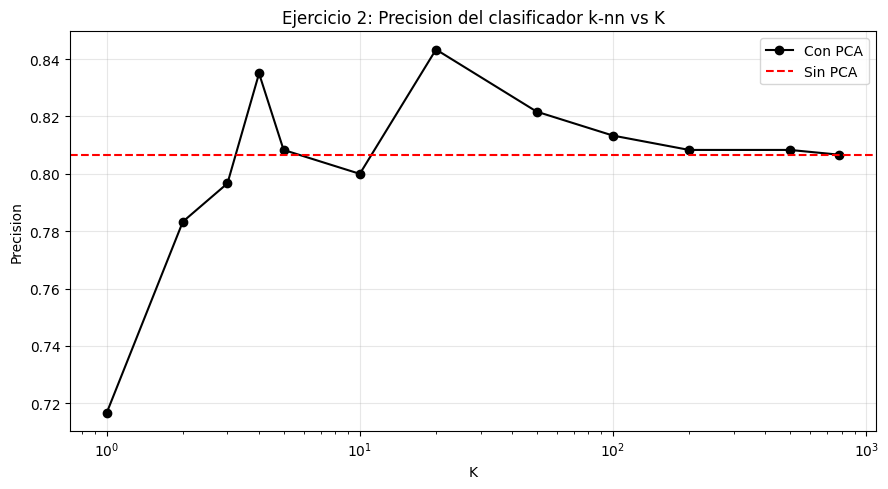

In [47]:
mu_total = X_total.mean(axis=0)
X_total_centrada = X_total - mu_total
Cov_total = np.cov(X_total_centrada, rowvar=False)

autovalores, autovectores = np.linalg.eigh(Cov_total)
idx = np.argsort(autovalores)[::-1]
autovalores, autovectores = autovalores[idx], autovectores[:, idx]

Precision_pca = []
for K in K_VALS:
    P_K = autovectores[:, :K]
    X_reducida = X_total_centrada @ P_K

    X_train, X_test, Y_train, Y_test = train_test_split(X_reducida, y_total, test_size=0.3, stratify=y_total, random_state=SEMILLA)

    Clasificador_k = KNeighborsClassifier(n_neighbors=5)
    Clasificador_k.fit(X_train, Y_train)
    
    Precision_k = accuracy_score(Y_test, Clasificador_k.predict(X_test))
    Precision_pca.append(Precision_k)

plt.figure(figsize=(9, 5))
plt.plot(K_VALS, Precision_pca, marker='o', label='Con PCA', color="k")
plt.axhline(precision, linestyle='--', label='Sin PCA', color="r")
plt.xscale('log')
plt.xlabel("K")
plt.ylabel("Precision")
plt.title("Ejercicio 2: Precision del clasificador k-nn vs K")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ejercicio 3 — Dispersión 2D: espacio original vs espacio PCA

En este ejercicio se visualizan las 500 imágenes de cada clase en 2D, comparando dos representaciones distintas.

### (a) Vectores originales truncados a las dos primeras componentes

Al tomar directamente los primeros dos píxeles de cada imagen, los puntos de las cuatro clases aparecen completamente mezclados sin ninguna separación visible. Esto tiene sentido porque los primeros dos píxeles no contienen información discriminativa: corresponden a posiciones fijas de la imagen que pueden tomar valores similares para cualquier clase. En consecuencia, esta representación es inútil para clasificación.

### (b) Espacio de componentes principales con K=2

Al proyectar los datos sobre los dos primeros componentes principales, se observa una separación parcial entre clases. Esto ocurre porque PCA elige las direcciones de mayor varianza en los datos, que tienden a coincidir con las diferencias más importantes entre clases. Con solo dos componentes no se logra una separación perfecta (consistente con que K=2 retiene apenas ~25-30% de la varianza), pero ya es notoriamente mejor que el caso (a).

### Impacto en la clasificación

La comparación entre ambos casos ilustra por qué PCA mejora el desempeño del clasificador k-nn: al proyectar en el espacio de componentes principales se compacta la información relevante y se descarta ruido, haciendo que las distancias entre puntos sean más significativas. Con los vectores originales truncados, las distancias que calcula el k-nn no tienen ninguna relación con la clase de cada imagen.

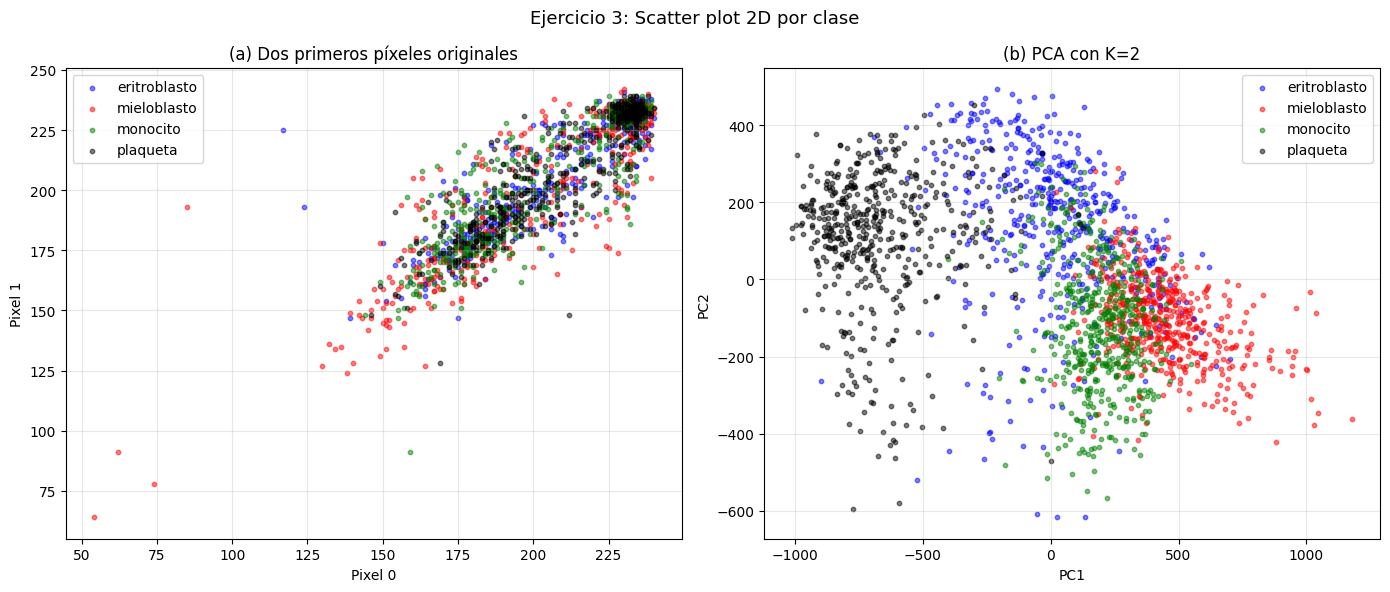

In [ ]:
colores_clase = ['b', 'r', 'g', 'k']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, clase in enumerate(CLASES):
    Datos_Clase = resultados[clase]["Datos de la Clase"]

    # (a) dos primeros píxeles del vector original
    axes[0].scatter(Datos_Clase[:, 0], Datos_Clase[:, 1], color=colores_clase[i], label=clase, alpha=0.5, s=10)

    # (b) PCA con K=2
    Datos_Clase_c = Datos_Clase - mu_total
    Y_pca = Datos_Clase_c @ Autovectores[:, :2]
    axes[1].scatter(Y_pca[:, 0], Y_pca[:, 1], color=colores_clase[i], label=clase, alpha=0.5, s=10)

axes[0].set_title("Dos primeros píxeles originales")
axes[0].set_xlabel("Pixel 1")
axes[0].set_ylabel("Pixel 2")

axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("PCA con K=2")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Scatter plot 2D por clase", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusiones

### Ejercicio 1 — Reconstrucción con PCA

PCA permite comprimir imágenes de 784 dimensiones a muchas menos conservando la mayor parte de la información. Con K=50 ya se recupera una imagen visualmente aceptable (con más del 90% de la varianza explicada y un MSE bajo), mientras que con K=2 la reconstrucción es muy pobre. Esto se refleja en las curvas: la varianza explicada crece rápidamente al principio y se estabiliza cerca de 1, mientras el MSE cae de forma pronunciada y se achata hacia 0 a medida que K crece.

### Ejercicio 2 — Clasificación k-nn con y sin PCA

Reducir la dimensionalidad no solo no perjudica la clasificación sino que con un K intermedio la mejora notablemente. El clasificador sin PCA obtuvo un accuracy de 0.8067, mientras que con PCA el mejor resultado fue 0.8433 para K=20, una mejora de casi 4 puntos porcentuales. Esto ocurre porque PCA elimina dimensiones ruidosas y deja solo la información relevante, haciendo que las distancias del k-nn sean más significativas. Con K muy chico el clasificador no tiene suficiente información, y con K grande el accuracy converge al caso sin PCA, ya que se recuperan prácticamente todas las dimensiones originales.

### Ejercicio 3 — Dispersión 2D

En el espacio original, tomar dos píxeles arbitrarios no separa las clases: los puntos aparecen completamente mezclados. En el espacio PCA con K=2 ya se observa una separación parcial entre clases, lo que confirma que PCA encuentra las direcciones realmente informativas. Esto es consistente con los resultados del Ejercicio 2: el espacio de componentes principales es mucho más adecuado para clasificación que el espacio original.

### Conclusión general

PCA es una herramienta poderosa para reducir dimensionalidad manteniendo la información relevante. Como se observó a lo largo de los tres ejercicios, permite comprimir datos, mejorar la clasificación y facilitar la visualización, todo mediante una misma transformación lineal que maximiza la varianza retenida.